In [1]:
import pandas as pd
import numpy as np
freq = pd.read_csv("data/raw/freMTPL2freq.csv")
sev = pd.read_csv("data/raw/freMTPL2sev.csv")

print(freq.shape)
print(sev.shape)
print(freq.head())
print(sev.head())

(678013, 12)
(26639, 2)
   IDpol  ClaimNb  Exposure  VehPower  VehAge  DrivAge  BonusMalus VehBrand  \
0    1.0        1      0.10         5       0       55          50      B12   
1    3.0        1      0.77         5       0       55          50      B12   
2    5.0        1      0.75         6       2       52          50      B12   
3   10.0        1      0.09         7       0       46          50      B12   
4   11.0        1      0.84         7       0       46          50      B12   

    VehGas Area  Density       Region  
0  Regular    D     1217  Rhone-Alpes  
1  Regular    D     1217  Rhone-Alpes  
2   Diesel    B       54     Picardie  
3   Diesel    B       76    Aquitaine  
4   Diesel    B       76    Aquitaine  
     IDpol  ClaimAmount
0     1552       995.20
1  1010996      1128.12
2  4024277      1851.11
3  4007252      1204.00
4  4046424      1204.00


Avant de merger, on vérifie l'état brut des données pour repérer les anomalies connues du dataset.

In [2]:
# Types de données
print(freq.dtypes)
print()

# Valeurs manquantes
print("Manquants freq:\n", freq.isna().sum())
print("Manquants sev:\n", sev.isna().sum())
print()

# Les fameuses anomalies documentées : Exposure > 1 an (impossible en théorie)
print("Exposure > 1:", (freq["Exposure"] > 1).sum())
print("Exposure max:", freq["Exposure"].max())
print()

# ClaimNb : valeurs extrêmes
print("ClaimNb value_counts:\n", freq["ClaimNb"].value_counts().sort_index())
print()

# IDpol dupliqués dans freq (ne devrait pas y en avoir)
print("Doublons IDpol dans freq:", freq["IDpol"].duplicated().sum())

# Un même IDpol peut apparaître plusieurs fois dans sev (plusieurs sinistres/police)
print("IDpol uniques dans sev:", sev["IDpol"].nunique(), "/ lignes sev:", len(sev))

IDpol         float64
ClaimNb         int64
Exposure      float64
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand       object
VehGas         object
Area           object
Density         int64
Region         object
dtype: object

Manquants freq:
 IDpol         0
ClaimNb       0
Exposure      0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Area          0
Density       0
Region        0
dtype: int64
Manquants sev:
 IDpol          0
ClaimAmount    0
dtype: int64

Exposure > 1: 1224
Exposure max: 2.01

ClaimNb value_counts:
 ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

Doublons IDpol dans freq: 0
IDpol uniques dans sev: 24950 / lignes sev: 26639


voici le raisonnement actuariel derrière chaque correction (c'est ça qu'un jury vous demandera de justifier) :
a) Exposure > 1 → on tronque à 1. Justification : la période d'observation du dataset est d'environ un an, donc une exposition > 1 est une erreur de données, pas un phénomène réel. df["Exposure"] = df["Exposure"].clip(upper=1.0)
b) ClaimNb extrêmes → on tronque à 4 (convention documentée dans plusieurs papiers de référence sur freMTPL2, notamment le tutoriel Wüthrich/Noll/Salzmann). Au-delà, ce sont presque certainement des erreurs de saisie et non des sinistres réels, et ça écraserait le GLM Poisson si on les gardait tels quels. df["ClaimNb"] = df["ClaimNb"].clip(upper=4)
c) sev avec IDpol dupliqués → on doit agréger par somme avant la jointure, sinon le merge va dupliquer les lignes de freq (une ligne par sinistre au lieu d'une ligne par police). C'est l'étape la plus fréquemment ratée par les débutants sur ce dataset.

 Agrégation de sev

In [3]:
sev_agg = sev.groupby("IDpol", as_index=False)["ClaimAmount"].sum()
print(sev_agg.shape)   # doit être (24950, 2) — un IDpol par ligne maintenant

(24950, 2)


jointure

In [4]:
df = freq.merge(sev_agg, on="IDpol", how="left")
print(df.shape)   # doit rester (678013, 13) — pas de duplication de lignes
df["ClaimAmount"] = df["ClaimAmount"].fillna(0.0)
print(df["ClaimAmount"].isna().sum())   # doit être 0 maintenant

(678013, 13)
0


correction

In [5]:
df["Exposure"] = df["Exposure"].clip(upper=1.0)
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)

print("Exposure max après correction:", df["Exposure"].max())
print("ClaimNb max après correction:", df["ClaimNb"].max())

Exposure max après correction: 1.0
ClaimNb max après correction: 4


Un réflexe à prendre systématiquement en actuariat : après chaque transformation, on vérifie que les grandeurs globales restent cohérentes avec ce qu'on sait du portefeuille.

In [6]:
# Fréquence globale du portefeuille
freq_globale = df["ClaimNb"].sum() / df["Exposure"].sum()
print(f"Fréquence globale : {freq_globale:.4f} sinistre/an/police")

# Cohérence : combien de polices ont un ClaimAmount > 0 vs ClaimNb > 0 ?
print("Polices avec ClaimNb > 0 :", (df["ClaimNb"] > 0).sum())
print("Polices avec ClaimAmount > 0 :", (df["ClaimAmount"] > 0).sum())

# Sévérité moyenne (sur les polices sinistrées uniquement)
sinistres = df[df["ClaimAmount"] > 0]
print(f"Sévérité moyenne : {sinistres['ClaimAmount'].mean():.2f} €")
print(f"Sévérité médiane : {sinistres['ClaimAmount'].median():.2f} €")
print(f"Sévérité max : {sinistres['ClaimAmount'].max():.2f} €")

Fréquence globale : 0.1006 sinistre/an/police
Polices avec ClaimNb > 0 : 34060
Polices avec ClaimAmount > 0 : 24944
Sévérité moyenne : 2401.75 €
Sévérité médiane : 1172.00 €
Sévérité max : 4075400.56 €


distribution sévérité:

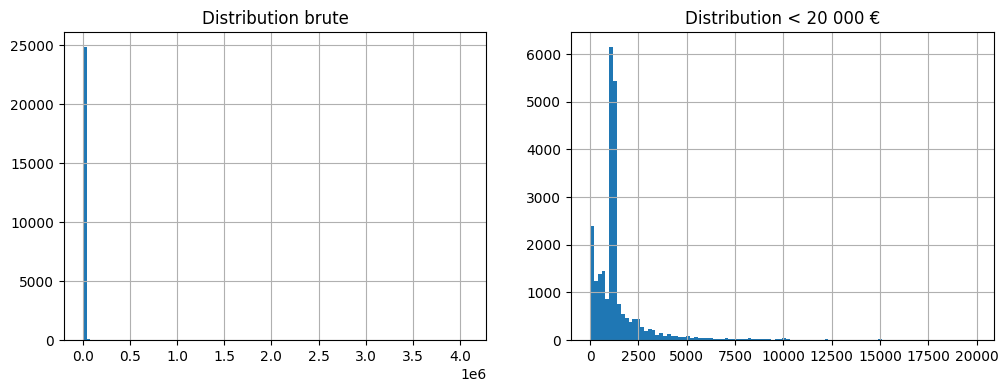

Sinistres > 100 000 € : 42
Sinistres > 1 000 000 € : 3


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sinistres["ClaimAmount"].hist(bins=100, ax=axes[0])
axes[0].set_title("Distribution brute")

sinistres[sinistres["ClaimAmount"] < 20000]["ClaimAmount"].hist(bins=100, ax=axes[1])
axes[1].set_title("Distribution < 20 000 €")

plt.show()

# Combien de sinistres extrêmes (> 100 000 €) ?
print("Sinistres > 100 000 € :", (sinistres["ClaimAmount"] > 100000).sum())
print("Sinistres > 1 000 000 € :", (sinistres["ClaimAmount"] > 1000000).sum())

In [ ]:
SEUIL_GRAVE = 100000

df["ClaimAmount_capped"] = df["ClaimAmount"].clip(upper=SEUIL_GRAVE)
df["is_large_claim"] = df["ClaimAmount"] > SEUIL_GRAVE

print("Nombre de sinistres graves :", df["is_large_claim"].sum())
print("Montant total sinistres graves :", df.loc[df["is_large_claim"], "ClaimAmount"].sum())
print("Montant total sinistres capés :", df["ClaimAmount_capped"].sum())
print("Part du risque grave dans le portefeuille :", 
      df.loc[df["is_large_claim"], "ClaimAmount"].sum() / df["ClaimAmount"].sum())

Nombre de sinistres graves : 42
Montant total sinistres graves : 14852323.960000003
Montant total sinistres capés : 49256892.539999984
Part du risque grave dans le portefeuille : 0.24791384076939155


            ClaimNb       Exposure  Frequence
BonusMalus                                   
50            18010  225152.650902   0.079990
51              540    8354.525595   0.064636
52              315    2724.605217   0.115613
53              198    1639.310809   0.120782
54              610    8697.427408   0.070136
55              414    3114.908284   0.132909
56              266    1782.150498   0.149258
57              666    8831.985709   0.075408
58              618    3217.368087   0.192082
59              171    1447.351380   0.118147


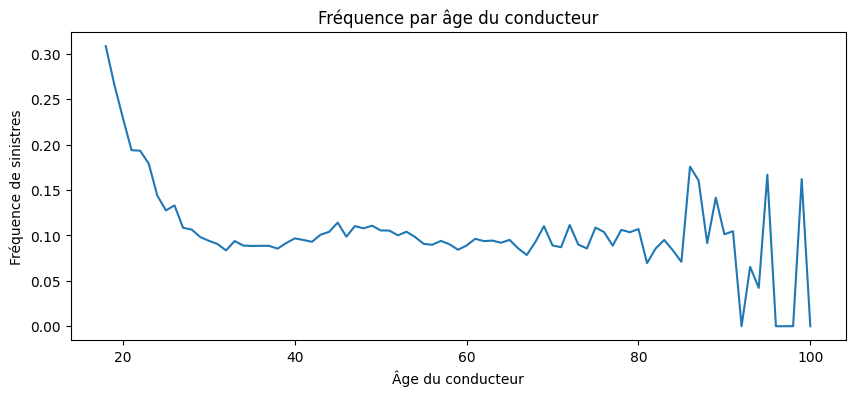

      ClaimNb       Exposure  Frequence
Area                                   
A        5056   61956.827712   0.081605
B        3800   43001.823931   0.088368
C        9875  104402.523784   0.094586
D        8390   77087.801692   0.108837
E        7804   63785.694270   0.122347
F        1131    8125.434074   0.139193
         ClaimNb       Exposure  Frequence
VehGas                                    
Diesel     16640  170587.553126   0.097545
Regular    19416  187772.552336   0.103402


In [ ]:
import matplotlib.pyplot as plt

# Fonction utilitaire : fréquence observée par groupe
def freq_par_groupe(data, var):
    g = data.groupby(var).agg(
        ClaimNb=("ClaimNb", "sum"),
        Exposure=("Exposure", "sum")
    )
    g["Frequence"] = g["ClaimNb"] / g["Exposure"]
    return g

# 1. BonusMalus (devrait être le facteur le plus discriminant)
bm = freq_par_groupe(df, "BonusMalus")
print(bm.head(10))

# 2. DrivAge
da = freq_par_groupe(df, "DrivAge")
plt.figure(figsize=(10, 4))
plt.plot(da.index, da["Frequence"])
plt.xlabel("Âge du conducteur")
plt.ylabel("Fréquence de sinistres")
plt.title("Fréquence par âge du conducteur")
plt.show()

# 3. Area
area = freq_par_groupe(df, "Area")
print(area)

# 4. VehGas
gas = freq_par_groupe(df, "VehGas")
print(gas)

In [ ]:
# Vérifier l'hypothèse "faible volume" pour les 80+ ans
old = df[df["DrivAge"] >= 80]
print("Exposition totale 80+ ans :", old["Exposure"].sum())
print("Nombre de sinistres 80+ ans :", old["ClaimNb"].sum())
print()
print(freq_par_groupe(df, "DrivAge").loc[80:])

Exposition totale 80+ ans : 6091.522723999
Nombre de sinistres 80+ ans : 583

         ClaimNb     Exposure  Frequence
DrivAge                                 
80           148  1382.331243   0.107066
81            80  1151.175579   0.069494
82            78   910.512909   0.085666
83            62   652.535572   0.095014
84            37   442.521858   0.083612
85            20   281.942740   0.070936
86            44   250.289141   0.175797
87            35   218.000000   0.160550
88            17   185.615479   0.091587
89            23   162.410000   0.141617
90            14   138.250000   0.101266
91            10    95.512740   0.104698
92             0    55.795464   0.000000
93             3    45.890000   0.065374
94             1    23.670000   0.042248
95             3    17.970000   0.166945
96             0    13.250000   0.000000
97             0     8.600000   0.000000
98             0     4.150000   0.000000
99             8    49.370000   0.162042
100            0    

In [ ]:
# Vue globale BonusMalus par tranches, pour lisser le bruit des petites classes
df["BM_bucket"] = pd.cut(df["BonusMalus"], bins=[49, 60, 80, 100, 125, 150, 350], 
                           labels=["50-60", "61-80", "81-100", "101-125", "126-150", "151+"])
bm_bucket = freq_par_groupe(df, "BM_bucket")
print(bm_bucket)

           ClaimNb       Exposure  Frequence
BM_bucket                                   
50-60        22563  273111.117915   0.082615
61-80         7057   53039.786794   0.133051
81-100        5094   28638.471750   0.177873
101-125       1178    3197.676094   0.368393
126-150        110     277.924712   0.395791
151+            54      95.128197   0.567655


C:\Users\marie\AppData\Local\Temp\ipykernel_17124\559321523.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(var).agg(


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# On utilise les buckets créés précédemment + les variables catégorielles brutes
# BM_bucket a déjà été créé à l'étape précédente

glm_data = df.copy()
glm_data["DrivAge_bucket"] = pd.cut(
    glm_data["DrivAge"],
    bins=[17, 20, 25, 30, 40, 50, 70, 120],
    labels=["18-20", "21-25", "26-30", "31-40", "41-50", "51-70", "71+"]
)
glm_data["VehAge_bucket"] = pd.cut(
    glm_data["VehAge"], bins=[-1, 0, 10, 200], labels=["neuf", "recent", "ancien"]
)

print(glm_data[["DrivAge_bucket", "VehAge_bucket", "BM_bucket"]].isna().sum())

DrivAge_bucket    0
VehAge_bucket     0
BM_bucket         0
dtype: int64


In [ ]:
formula = (
    "ClaimNb ~ C(DrivAge_bucket) + C(VehAge_bucket) + C(BM_bucket) "
    "+ C(Area) + C(VehGas) + C(VehBrand) + C(Region) + Density_log"
)

# Il faut ajouter Density_log si vous ne l'avez pas encore dans glm_data
glm_data["Density_log"] = np.log(glm_data["Density"])

model_glm = smf.glm(
    formula=formula,
    data=glm_data,
    family=sm.families.Poisson(),
    offset=np.log(glm_data["Exposure"])
).fit()

print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   677962
Model Family:                 Poisson   Df Model:                           50
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4111e+05
Date:                Fri, 10 Jul 2026   Deviance:                   2.1290e+05
Time:                        09:43:19   Pearson chi2:                 1.55e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01614
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [ ]:
# Corrélation entre Area (encodée en rang A=0...F=5) et Density_log
area_order = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5}
glm_data["Area_rank"] = glm_data["Area"].map(area_order)

print(glm_data[["Area_rank", "Density_log"]].corr())

             Area_rank  Density_log
Area_rank     1.000000     0.970618
Density_log   0.970618     1.000000


In [ ]:
formula_v2 = (
    "ClaimNb ~ C(DrivAge_bucket) + C(VehAge_bucket) + C(BM_bucket) "
    "+ C(VehGas) + C(VehBrand) + C(Region) + Density_log"
)

model_glm_v2 = smf.glm(
    formula=formula_v2,
    data=glm_data,
    family=sm.families.Poisson(),
    offset=np.log(glm_data["Exposure"])
).fit()

print("Déviance modèle v1 (avec Area):", model_glm.deviance)
print("Déviance modèle v2 (sans Area):", model_glm_v2.deviance)
print("AIC v1:", model_glm.aic)
print("AIC v2:", model_glm_v2.aic)

Déviance modèle v1 (avec Area): 212903.19307962217
Déviance modèle v2 (sans Area): 212910.34749786658
AIC v1: 282321.62729066086
AIC v2: 282318.7817089051


In [ ]:
# Depuis la racine du projet, en Python interactif ou dans un notebook
from src.common.config import load_config

config = load_config()
print(config)
print(config["pricing"]["large_claim_threshold"])

{'paths': {'raw_freq': 'data/raw/freMTPL2freq.csv', 'raw_sev': 'data/raw/freMTPL2sev.csv', 'processed_dir': 'data/processed'}, 'pricing': {'large_claim_threshold': 100000, 'exposure_cap': 1.0, 'claim_nb_cap': 4, 'train_test_split': {'train': 0.6, 'valid': 0.2, 'test': 0.2, 'seed': 123}, 'driv_age_bins': [17, 20, 25, 30, 40, 50, 70, 120], 'driv_age_labels': ['18-20', '21-25', '26-30', '31-40', '41-50', '51-70', '71+'], 'veh_age_bins': [-1, 0, 10, 200], 'veh_age_labels': ['neuf', 'recent', 'ancien'], 'bm_bins': [49, 60, 80, 100, 125, 150, 350], 'bm_labels': ['50-60', '61-80', '81-100', '101-125', '126-150', '151+']}}
100000
